# LABORATORIO 1.2: Regresión logística, entropía cruzada y capas ocultas.

El objetivo de este segundo laboratorio es tener una primera aproximación computacional al ajuste de una regresión logística. A diferencia del laboratorio anterior (1.1), esta vez usaremos la entropía cruzada como función de pérdida a minimizar. Adicionalmente, tendremos una primera aproximación a el funcionamiento de capas ocultas.

Seguiremos usando la misma problemática del laboratorio 1.1: deseamos crear un clasificador binario que, usando la variable precipitación mensual, pueda predecir si habrá o no un pico de casos de dengue. Usando esta inferencia se espera poder desarrollar medidas preventivas y estar preparados para atender el exceso de casos de esta enfermedad tropical.

1. Lluvias mensuales (unidades = mm de agua).
2. Pico (1) o no (0) casos de dengue en cada mes.

## Fase 1 - Carga de datos y exploración visual

**Objetivo:** cargar los datos del archivo .xlsx y construir unas primeras gráficas de las dos series de tiempo para hacer un primer analisis visual de los datos de entrada..

Para hacer esto, usaremos los paquetes `numpy` para el manejo de estructuras tipo vector, `matplotlib` para hacer gráficos, y `pandas` para manejar estructuras de datos tipo data.frame. Para poder usarlos, los importaremos en nuestro espacio de trabajo:

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Para cargar los datos, usamos la función `read_excel` del paquete `pandas`. Esta función tiene un único parámetro obligatorio (la ubicación del archivo de Excel a leer) y varios opcionales (disponibles en https://pandas.pydata.org/docs/reference/api/pandas.read_excel.html). El output de esta función es una variable tipo DataFrame, que en este caso tiene 3 columnas (t, Lluvias, Pico de casos).


**Nota:** Es importante tener el archivo de los datos "datosDengueTangamandapio.xlsx" en la misma carpeta que el código para poderlo cargarlo usando el código suministrado. Si se encuentra en otra carpeta, es necesario añadir toda la ruta de localización.

In [43]:
# Leer el archivo Excel
df = pd.read_excel('datosDengueTangamandapio.xlsx')

Ahora extraeremos los valores de las columnas de las columnas de este DataFrame `df`.

Se puede descomentar las últimas 6 líneas de código para ver cuál es el tipo y tamaño de cada variable.

In [44]:
# Extraer las columnas como vectores (arrays de NumPy)
x_real = df['Lluvias'].values.reshape(-1,1)
y_real = df['Pico de casos'].values.reshape(-1,1)
t = df['t']

# OPCIONAL: Verificamos el tipo y tamaño de cada uno de los vectores
print("Tamaño de t:", t.shape)
print("Tipo de t:", t.dtype, "\n")
print("Tamaño de x_real:", x_real.shape)
print("Tipo de x_real:", x_real.dtype, "\n")
print("Tamaño de y_real:", y_real.shape)
print("Tipo de y_real:", y_real.dtype)

Tamaño de t: (100,)
Tipo de t: datetime64[us] 

Tamaño de x_real: (100, 1)
Tipo de x_real: float64 

Tamaño de y_real: (100, 1)
Tipo de y_real: int64


La primera gráfica que construiremos es una serie de tiempo para ambas variables (precipitación de lluvia y casos de dengue). Esta gráfica tendrá ambas series de tiempo, usando dos ejes Y para poder mostrar el comportamiento de ambas variables. Este tipo de gráficas con doble eje vertical permite ver en simultaneo ambas series de tiempo, evitando el problema de no poder apreciar el comportamiento de una de las variables por diferencias de escalas.

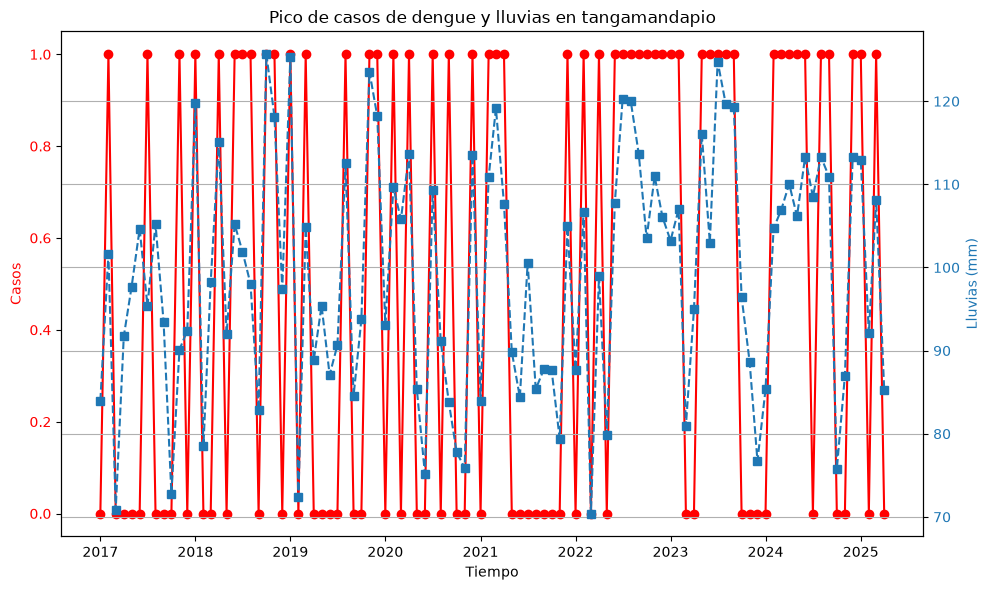

In [45]:
# Creamos la figura y eje principal (izquierdo)
fig1 = plt.figure(figsize=(10, 6))      # El 10 y 6 son las dimensiones (horizontal,vertical) de la gráfica en pulgadas

# Creamos el primer subplot
ax1 = fig1.subplots()
# Definimos el título del eje X
ax1.set_xlabel('Tiempo')
# Graficamos la primera serie de datos (casos)
color_eje1 = 'red'
ax1.plot(t, y_real, color=color_eje1, marker='o', label='Casos')
# Definimos el título del primer eje Y (izquierda)
ax1.set_ylabel('Casos', color=color_eje1)
ax1.tick_params(axis='y', labelcolor=color_eje1)

# Creamos el segundo subplot que compartirá el mismo eje X que el primero
ax2 = ax1.twinx()
# Graficamos y formateamos esta serie de manera similar a la anterior
color_eje2 = 'tab:blue'
ax2.plot(t, x_real, color=color_eje2, marker='s', linestyle='--', label='Lluvias')
ax2.set_ylabel('Lluvias (mm)', color=color_eje2)
ax2.tick_params(axis='y', labelcolor=color_eje2)

# Título y formato de la figura combinada
plt.title('Pico de casos de dengue y lluvias en tangamandapio')
fig1.tight_layout()
plt.grid(True)
plt.show()

La segunda gráfica será un *scatterplot*, donde exploraremos la correlación entre ambas variables. En este caso, usaremos las lluvias mensuales en el eje X al ser una variable continua (mm de columna de agua de lluvia) y también por ser la variable de entrada con la cual queremos predecir si habrá o no picos de casos (la cuál irá en el eje Y).

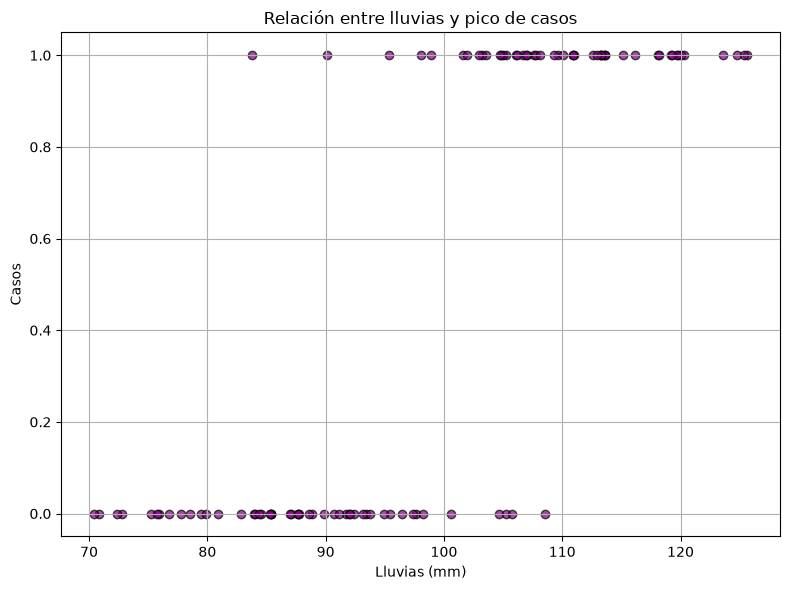

In [46]:
# Creamos el gráfico de dispersión o scatterplot
fig2 = plt.figure(figsize=(8,6))
plt.scatter(x_real, y_real, color='purple', edgecolor='black', alpha=0.7)

# Formateamos la gráfica (títulos de los ejes, título de la gráfica)
plt.xlabel('Lluvias (mm)')
plt.ylabel('Casos')
plt.title('Relación entre lluvias y pico de casos')
plt.grid(True)
plt.tight_layout()
plt.show()

En ambas gráficas se puede observar que existe una relación entre ambas variables.

En el laboratorio 1.1 ajustamos un modelo lineal a estos datos. Sin embargo, es claro al observar el *scatterplot* la característica binaria de la variable "Pico de casos" y que una regresión lineal no es adecuada para estos datos.

Por este motivo, vamos a ajustar una regresión logística.



## Fase 2 - Reescalado y definición de la función de pérdida

Al igual que en laboratorio pasado, lo primero que haremos es reescalar ambas variables para facilitar el ajuste del modelo. El número de casos (`Y`) ya está "escalado" porque sus valores están entre 0 y 1. En cambio, la cantidad de lluvia tiene valores desde 70 mm a 110 mm.

In [47]:
# Reescalamos
X_escalado = (x_real - np.mean(x_real)) / np.std(x_real)
Y_escalado = y_real

**Pregunta:** ¿por qué hacemos una normalización usando el promedio y la desviación estándar (*Z-score normalization*)? ¿Qué problemas podríamos enfrentar si hacemos una normalización usando el rango de la variable ($max(x)-min(x)$) en vez la desviación estándar?

Se utiliza la normalización Z-score porque centra los datos alrededor de cero y los escala según su desviación estándar.

Esto facilita el entrenamiento del modelo, ya que las variables quedan en una escala comparable y los valores suelen estar alrededor de $-1$ y $1$. En una distribución aproximadamente normal, cerca del 68% de los datos se encuentra dentro de ese intervalo, aunque este porcentaje puede variar según la distribución.

Si normalizamos utilizando únicamente el rango, $max(x)-min(x)$, los resultados pueden ser más sensibles a los valores atípicos. Un solo valor extremadamente grande o pequeño puede ampliar mucho el rango y hacer que la mayoría de los datos queden concentrados en una región muy pequeña. Además, esta normalización no centra necesariamente los datos alrededor de cero, lo que puede dificultar la optimización y afectar el comportamiento de los gradientes. Por estas razones, la normalización Z-score suele ser más conveniente cuando se desea centrar los datos y reducir la influencia de las diferencias de escala.

Segundo, vamos a definir una función para nuestro modelo sigmoide. Esta función tendrá como **input** las siguientes variables $ $:

*   Valor de lluvias (normalizadas)
*   Parámetros del modelo:
    *   Peso $ w $
    *   Sesgo $ b $

En esta función primero tenemos una ecuación linea que luego pasa por una función sigmoide. Esta función sería nuestra función de salida o de activación:

In [48]:
# Función de nuestro modelo
# INPUT: vector X (lluvias normalizadas), y los parámetros w y b.
def predict(X, w, b):
    y = X * w + b   # Modelo lineal
    z = 1/(1+np.exp(-y))    #Función sigmoide de salida o activación
    return z

Posteriormente, definiremos la función a minimizar (**función de perdida**). A diferencia de la vez pasada donde usamos la suma de los errores cuadrados (MSE), esta función de pérdida se definirá usando la entropía cruzada:

**Importante:** A nivel matemático, la función sigmoide nunca es 0 ni 1 ya que son los límites en menos infinito e infinito respectivamente. A nivel computacional, una aproximación puede hacer que tome estos valores y por ende tengamos errores en el cálculo de los logarítmos. Por ende, usamos un error *epsilon* de *1e-8*, para evitar que en esos casos se evaluen logarítmos de 0.

In [49]:
# Función de perdida (entropía cruzada)
# INPUT:
#   y_pred: nuestra predicción
#   y_true: las observaciones
def loss_ce(y_pred, y_true):
    epsilon = 1e-8
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))

Definimos también las derivadas parciales de esta función respecto a cada parámetro (peso: $ \frac{\partial f}{\partial w} $ ; sesgo: $ \frac{\partial f}{\partial b} $):

**Pregunta:** ¿cómo obtenemos estas derivadas de manera analítica? **Hint:** tener cuidado con la notación ($z,y$)

Usamos *backpropagation*, es decir, la regla de la cadena, para obtener las derivadas de la función de pérdida con respecto a los parámetros del modelo.

Para evitar confusiones, usamos la notación convencional: primero calculamos la combinación lineal
$$
z = Xw+b,
$$
y luego aplicamos la función sigmoide para obtener la predicción
$$
y=\sigma(z).
$$
La función de pérdida para una observación es
$$
L=-\left[y_{\mathrm{real}}\log(y)+(1-y_{\mathrm{real}})\log(1-y)\right].
$$
Aplicando la regla de la cadena, se obtiene
$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial y}
\frac{\partial y}{\partial z}
\frac{\partial z}{\partial w}
=
(y-y_{\mathrm{real}})X,
$$
y, de manera análoga,
$$
\frac{\partial L}{\partial b}
=
\frac{\partial L}{\partial y}
\frac{\partial y}{\partial z}
\frac{\partial z}{\partial b}
=
y-y_{\mathrm{real}}.
$$
Al calcular el promedio sobre todas las observaciones, las derivadas que usamos en el código son
$$
\frac{\partial L}{\partial w}
=
\operatorname{mean}\left((y-y_{\mathrm{real}})X\right),
\qquad
\frac{\partial L}{\partial b}
=
\operatorname{mean}(y-y_{\mathrm{real}}).
$$
Estas expresiones corresponden a `dw` y `db` en la función `grad_ce`. En el código, sin embargo, la variable llamada `y` representa la combinación lineal $Xw+b$, mientras que la variable llamada `z` representa la salida de la sigmoide. Por eso, allí `z` equivale a la predicción $y$ de la notación convencional.

In [50]:
# Función que calcula para los valores de un vector X y los valores predichos y observados, cuanto vale la pendiente sobre CE respecto a w y a b.
def grad_ce(X, y_true, y_pred):
    dw = np.mean((y_pred - y_true) * X)
    db = np.mean(y_pred - y_true)
    return dw, db

Y una función que permite buscar el mínimo de la función de perdida a partir de navegar por el gradiente:

In [51]:
# Entrenamiento genérico por grádiente:
# A partir de una condición inicial "realística" sobre w y b, se navega usando un learning rate y se hace un número "epoch" de pasos en esta navegación.
# INPUTS:
#   X, y: valores reales (medidos) de las variables X y Y
#   loss_fn, grad_fn: función de pérdida, y las derivadas de esas funciones de pérdida respecto a los parámetros
#   param_0 = "educated guess" de los valores de los parámetros
#   lr: learning rate
#   epochs: número de épocas
def train(X, y, loss_fn, grad_fn, param_0, lr=0.1, epochs=1000):
    # Hacemos un "educated guess" de los valores de los parámetros
    w = param_0[0]
    b = param_0[1]

    # Inicializamos un vector donde almacenaremos el valor de la función de pérdida en cada época
    losses = []

    for epoch in range(epochs):
        # Para cada época empezamos calculando el valor predicho de la variable de respuesta
        y_pred = predict(X, w, b)
        # Calculamos el valor de la función de pérdida (en este caso, es el MSE)
        loss = loss_fn(y_pred, y)
        # Calculamos el gradiente de la función de pérdida
        dw, db = grad_fn(X, y, y_pred)
        # Avanzamos en el landscape de optimización usando el gradiente. Recordemos que el tamaño del paso está determinado también por el learning rate
        w -= lr * dw
        b -= lr * db
        # Guardamos el valor de pérdidas para luego hacer una gráfica
        losses.append(loss)

        if epoch %10 ==0:
            print(f'Loss at epoch {epoch}: {loss}')

        if epoch > 0 and abs(losses[-1] - losses[-2]) < 1e-10:
            # Paramos el ciclo si el cambio en la función de pérdida es muy pequeño entre épocas
            break
    return w, b, losses

Ya teniendo nuestrás funciones listas, procedemos a hacer el ajuste sobre nuestros datos.

In [52]:
# Ajustar con entropía cruzada
w_ce, b_ce, loss_ce_list = train(X_escalado, Y_escalado, loss_ce, grad_ce, [0.66, -0.2])

print("\n")
print("RESULTADOS AJUSTE ---------------------------------------------------------")
print("Peso ajustado:", w_ce)
print("Bias (sesgo) ajustado:", b_ce)

Loss at epoch 0: 0.4922586494514221
Loss at epoch 10: 0.44339891473004855
Loss at epoch 20: 0.4096789878066319
Loss at epoch 30: 0.3853071278813477
Loss at epoch 40: 0.36700916010579676
Loss at epoch 50: 0.35284147887638445
Loss at epoch 60: 0.34159360923539994
Loss at epoch 70: 0.33247845557043815
Loss at epoch 80: 0.3249646236578679
Loss at epoch 90: 0.31868151872435463
Loss at epoch 100: 0.31336334277410777
Loss at epoch 110: 0.30881477348024633
Loss at epoch 120: 0.30488920808657805
Loss at epoch 130: 0.301474551587484
Loss at epoch 140: 0.29848368150002286
Loss at epoch 150: 0.29584789589802624
Loss at epoch 160: 0.2935123141895485
Loss at epoch 170: 0.2914325861147624
Loss at epoch 180: 0.28957249574791705
Loss at epoch 190: 0.28790218955636204
Loss at epoch 200: 0.2863968471810714
Loss at epoch 210: 0.285035671287334
Loss at epoch 220: 0.2838011107135054
Loss at epoch 230: 0.28267825647891553
Loss at epoch 240: 0.2816543674423799
Loss at epoch 250: 0.28071849430562573
Loss at ep

Ya teniendo nuestro modelo ajustado, por último gráficaremos los resultados.

Graficaremos el ajuste de este modelo sobre los datos originales. No debemos olvidar que el ajuste lo hacemos con los datos escalados, por lo que para poder graficar el output del modelo se deben "desescalar" los valores de lluvia:

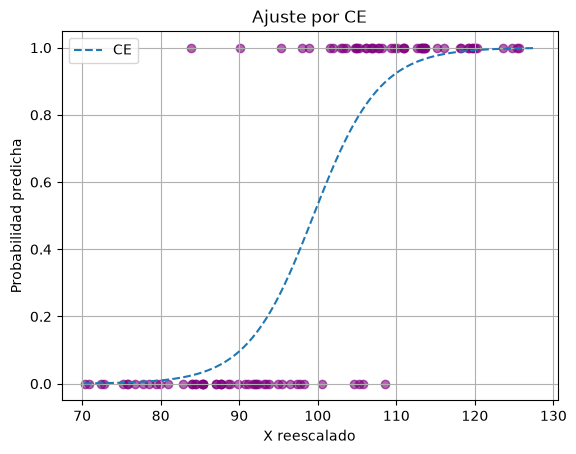

In [53]:
# Crear nueva variable para hacer las predicciones de nuestra regresión.
# La declaramos escalada para luego desescalarla y poderla gráficar junto a los datos crudos.
X_plot_escalado = np.linspace(-2, 2, 100).reshape(-1, 1)
x_plot_desescalado = (X_plot_escalado*np.std(x_real)) + np.mean(x_real)
# Predicciones sobre nuestro modelo usando los parámetros ya ajustados
y_pred_ce = predict(X_plot_escalado, w_ce, b_ce)

# Plot que muestra los datos crudos y nuestro modelo
plt.plot(x_plot_desescalado, y_pred_ce, label="CE", linestyle='--')
plt.scatter(x_real, y_real,color='purple' ,alpha=0.6)
plt.legend()
plt.title("Ajuste por CE")
plt.xlabel("X reescalado")
plt.ylabel("Probabilidad predicha")
plt.grid()
plt.show()

También hacemos un plot que nos permita ver como decae la función de perdida al usar el método del gradiente:

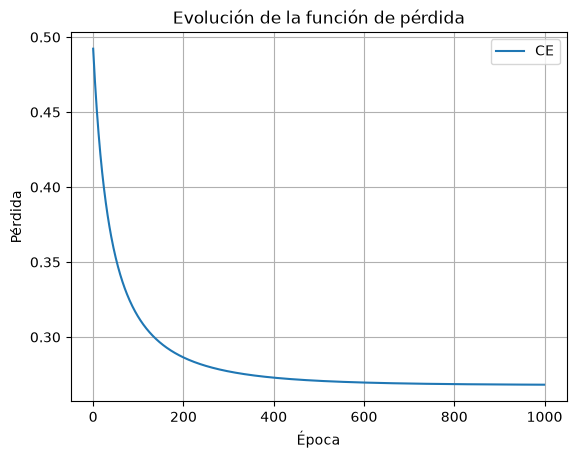

In [54]:
# Curva de perdida
plt.plot(loss_ce_list, label="CE")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.title("Evolución de la función de pérdida")
plt.grid()
plt.show()

## Fase 3 - Métricas de desempeño

Una ves tenemos evaluado el modelo, podemos obtener su desempeño usando varias métricas. Aca definiremos una *matriz de confusión*, que permite ver verdaderos positivos *TP* (Predicciones de 1 correctas), verdaderos negativos *TN* (Predicciones de 0 correctas), falsos positivos *FP* (Predicciones de 1 incorrectas), y falsos negativos *FN* (Predicciones de 0 incorrectas):

| Real / Predicha | Pico (1)                | No pico (0)             |
|-----------------|-------------------------|-------------------------|
| **Pico (1)**    | Verdadero positivo (TP) | Falso negativo (FN)     |
| **No pico (0)** | Falso positivo (FP)     | Verdadero negativo (TN) |

Con base en estos 4 valores podemos obtener varios índices que nos permiten observar que tan bien se ajusta el modelo a los datos.

Definiremos una función que nos sirva para calcular estos parámetros para cualquier modelo que tengamos:

In [55]:
# Función para evaluar el desempeño de nuestro modelo
# INPUT:
#   umbral = límite del valor de salida (sigmoide) a partir del cual consideramos que es un resultado positivo (= sí hay un pico en los casos)
def evaluar_manual(y_true, y_probs, umbral=0.5, epsilon = 1e-8):
    # Convertimos nuestros valores "continuos" de predicción en un binario (0,1) usando nuestro valor de umbral
    y_pred = (y_probs >= umbral).astype(int)

    # Ya con los valores binarios podemos contar qué cantidad de predicciones son verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos
    TP = np.sum((y_pred == 1) & (y_true == 1)) #Verdaderos positivos
    TN = np.sum((y_pred == 0) & (y_true == 0)) #Verdaderos negativos
    FP = np.sum((y_pred == 1) & (y_true == 0)) #Falsos positivos
    FN = np.sum((y_pred == 0) & (y_true == 1)) #Falsos negativos

    # El "accuracy" o exactitud mide cuántas predicciones (positivas o negativas) fueron correctas
    accuracy = (TP + TN) / len(y_true)

    # La precisión mide el total de predicciones positivas correctas (true positivies) respecto al total de predicciones positivas
    precision = TP / (TP + FP + epsilon)

    # El "recall" o exhaustividad
    recall = TP / (TP + FN + epsilon)

    # Y el valor F
    f1 = 2 * precision * recall / (precision + recall + epsilon)

    # Imprimimos los resultados de estos cálculos
    print("Parámetros de desempeño del modelo (calculados manualmente):")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("\n")
    print("Matriz de confusión:")
    print(f"TP: {TP} | FP: {FP}")
    print(f"FN: {FN} | TN: {TN}")

Teniendo definida nuestra función, la aplicamos a los resultados de nuestro modelo y analizamos el desempeño de nuestro clasificador. Para hacer esto, primero debemos calcular las predicciones del modelo a los datos de entrada, y luego usamos la función de cálculo de parámetros de desempeño:

In [56]:
# Obtenemos las probabilidades al aplicar nuestro modelo (es decir, usando los parámetros w y b que estimamos via CE y el método del gradiente)
probs_ce  = predict(X_escalado, w_ce,  b_ce)

# Evaluación de estos resultados:
print("Evaluación modelo con Entropía Cruzada:\n")
evaluar_manual(Y_escalado, probs_ce)

Evaluación modelo con Entropía Cruzada:

Parámetros de desempeño del modelo (calculados manualmente):
Accuracy  : 0.9000
Precision : 0.9000
Recall    : 0.9000
F1-score  : 0.9000


Matriz de confusión:
TP: 45 | FP: 5
FN: 5 | TN: 45


## Fase 4 - Usando 1 capa oculta

Ahora, vamos de volver a definir el mismo modelo pero usando 1 capa oculta, la cual tendra multiples neuronas y no la vamos a entrenar (es decir, cada neurona tendra valores al azar de *peso* y *sesgo*). ¿Qué vamos a entrenar? La neurona de salida, que usa el output de esta capa oculta.

Para esto, usamos el comando *ravel* sobre nuestros datos de entrada para evitar que sean multidimensionales y tengamos problemas en las operaciones matriciales.

In [57]:
X_escalado = np.ravel(X_escalado)
Y_escalado = np.ravel(Y_escalado)

Además, asignamos valores de bias $b$ y peso $w$ a cada neurona de la capa oculta:

In [58]:
# ===== Definición de nuestra capa oculta fija =====

# Fijamos la semilla para nuestro generador de números aleatorios, sólo para tener los mismos resultados cada vez que corramos este código
np.random.seed(0)

# Definimos los valores de b y w de las neuronas de la capa oculta
N_neu = 10
W1 = np.random.randn(1, N_neu)   # Entrada: (Vector datos)= 1 dimensión, neuronas= N_neu dimensiones)
b1 = np.random.randn(N_neu)      # Entrada: (Vector datos)= neuronas= N_neu dimensiones)

# Imprimimos estos valores de w y b
print(f'Pesos: {W1}')
print(f'Sesgos: {b1}')

Pesos: [[ 1.76405235  0.40015721  0.97873798  2.2408932   1.86755799 -0.97727788
   0.95008842 -0.15135721 -0.10321885  0.4105985 ]]
Sesgos: [ 0.14404357  1.45427351  0.76103773  0.12167502  0.44386323  0.33367433
  1.49407907 -0.20515826  0.3130677  -0.85409574]


Ahora tenemos que definir la transformación que hará nuestra capa oculta.

Acá es importante tener en cuenta que la salida serán $N_\text{neu}$ vectores de tamaño del tamaño de nuestros datos. Por ende, esos $N_\text{neu}$ vectores tendran cada uno un peso entrenable en nuestra neurona de salida.

In [59]:
def hidden_layer(X):
    z = np.outer(X, W1.flatten()) + b1  # Tamaño de este array: (n datos, N_lay)

    # Aplicamos la función sigmoide
    return 1 / (1 + np.exp(-z))         # Tamaño de este array: (n datos, N_lay)

Ya con nuestra capa oculta definida, podemos definir nuestro modelo:

In [60]:
# ===== Definición de nuestra capa de salida entrenable =====

def predict_hidd(X, w, b):
    # Calculamos el output de nuestra capa oculta
    h = hidden_layer(X)         # Tamaño de este array: (n datos, N_lay)

    # Esos ouputs serán el input de nuestra capa de salida, que también tendrá la función sigmoide como función de activación
    y = h @ w + b               # Tamaño de h: (n datos, N_lay). Tamaño de w:(N_lay, 1) -> Tamaño de h @ w: (n datos, 1)
    return 1 / (1 + np.exp(-y)) # Tamaño de este array: (n_datos, 1)

Ahora, definimos nuestra función de pérdida (igual a la anterior, usando entropía cruzada):

In [61]:
# Funcion de perdida por entropía cruzada
def loss_ce(y_pred, y_true):
    epsilon = 1e-8
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))  # Tamaño de este array: (n datos)

Y también definimos el gradiente de nuestra función de pérdida.

**Nota:** en este caso, para calcular el gradiente hay que tener en cuenta que el error ($y_\text{pred} - y_\text{real}$) solo como resta es un vector plano (1D; dimensión = número de observaciones) que no permite hacer producto externo con los *N_lay* vectores de salida de la capa oculta. Por esto gracias a *np.newaxis* definimos una nueva dimensión en este array que permita representar este error como una matriz (n,1):

In [62]:
# Funcion del gradiente
def grad_ce(X, y_true, y_pred):
    h = hidden_layer(X)                       # Tamaño: (n datos, N_lay)
    error = (y_pred - y_true)                 # Tamaño: (n datos,)
    error = error[:, np.newaxis]              # Tamaño: (n,1): Importante para poder hacer el producto externo con H que permite obtener el gradiente en w para los N_lay pesos.
    dw = np.mean(h * error, axis=0)           # Tamaño: (N_lay,)
    db = np.mean(y_pred - y_true)             # Tamaño: escalar
    return dw, db

Ahora, definimos el entrenamiento sobre los *N_lay* pesos de nuestra neurona entrenable:

In [63]:
# Entrenamiento genérico por grádiente:
def train(X, y, loss_fn, grad_fn, lr=0.1, epochs=100000):
    # En vez de tener un "educated guess" de los valores de los parámetros como hicimos antes, esta vez los inicializamos aleatoriamente
    w = np.random.randn(N_neu)  # Tamaño: (N_neu,)
    b = np.random.randn()       # Tamaño: escalar
    # Vector donde almacenaremos el valor de la función de pérdida en cada época
    losses = []

    for epoch in range(epochs):
        # Calculamos el valor predicho de la variable de respuesta
        y_pred = predict_hidd(X, w, b)
        # Calculamos el valor de la función de pérdida (en este caso, es el CE)
        loss = loss_fn(y_pred, y)
        # Calculamos el gradiente de la función de pérdida
        dw, db = grad_fn(X, y, y_pred)
        # Avanzamos en el landscape de optimización usando el gradiente
        w -= lr * dw
        b -= lr * db
        # Guardamos el valor de pérdidas de esta época
        losses.append(loss)
        # Early stop
        if epoch % 100 == 0:
            print(f"Epoch {epoch} - Loss: {loss:.6f}")
    return w, b, losses

Después de definir todas las funciones que necesitamos, hacemos el entrenamiento con nuestros datos:

In [64]:
w_final, b_final, losses = train(X_escalado, Y_escalado, loss_ce, grad_ce, lr=0.1, epochs=1000)

print("\n")
print("RESULTADOS AJUSTE ---------------------------------------------------------")
print("Peso ajustado:", w_final)
print("Bias (sesgo) ajustado:", b_final)

Epoch 0 - Loss: 0.785796
Epoch 100 - Loss: 0.418912
Epoch 200 - Loss: 0.345792
Epoch 300 - Loss: 0.314874
Epoch 400 - Loss: 0.298900
Epoch 500 - Loss: 0.289620
Epoch 600 - Loss: 0.283804
Epoch 700 - Loss: 0.279963
Epoch 800 - Loss: 0.277329
Epoch 900 - Loss: 0.275469


RESULTADOS AJUSTE ---------------------------------------------------------
Peso ajustado: [-0.86590126 -0.09025125  1.29797544  1.32696134  3.8703186  -3.89044193
 -0.1249353  -1.11649933  0.50309362  1.65201809]
Bias (sesgo) ajustado: -1.3112878158261065


Por último, evaluamos su capacidad predictiva:

In [65]:
# Obtenemos las probabilidades al aplicar nuestro modelo (es decir, usando los parámetros w y b que estimamos via CE y el método del gradiente)
probs_ce  = predict_hidd(X_escalado, w_final,  b_final)

# Evaluación de estos resultados:
print("Evaluación modelo con Entropía Cruzada:\n")
evaluar_manual(Y_escalado, probs_ce)

Evaluación modelo con Entropía Cruzada:

Parámetros de desempeño del modelo (calculados manualmente):
Accuracy  : 0.9100
Precision : 0.9020
Recall    : 0.9200
F1-score  : 0.9109


Matriz de confusión:
TP: 46 | FP: 5
FN: 4 | TN: 45


Ahora hacemos una gráfica para comparar los resultados de usar una única neurona vs. una capa escondida:

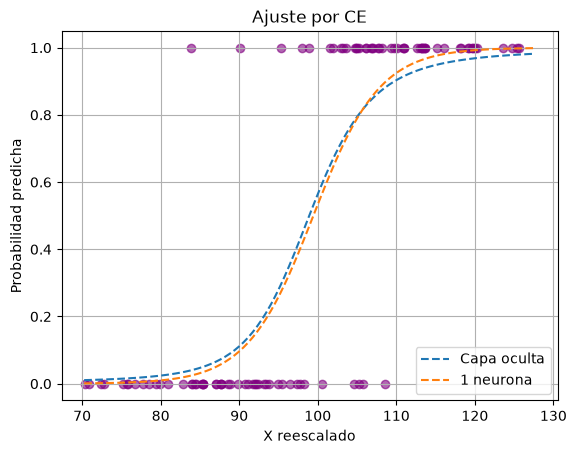

In [66]:
# Crear nueva variable para hacer las predicciones de nuestra regresión. La declaramos escalada para luego desescalarla y poderla gráficar junto a los datos crudos.
X_plot_escalado = np.linspace(-2, 2, 100).reshape(-1, 1)
x_plot_desescalado = (X_plot_escalado*np.std(x_real)) + np.mean(x_real)
# Predicciones sobre nuestro modelo usando los parámetros ya ajustados
y_pred_hid_plot = predict_hidd(X_plot_escalado.flatten(), w_final, b_final)

# Plot que muestra los datos crudos y nuestro modelo
plt.plot(x_plot_desescalado, y_pred_hid_plot, label="Capa oculta", linestyle='--')
plt.plot(x_plot_desescalado,y_pred_ce,label="1 neurona",linestyle='--')
plt.scatter(x_real, y_real,color='purple' ,alpha=0.6)
plt.legend()
plt.title("Ajuste por CE")
plt.xlabel("X reescalado")
plt.ylabel("Probabilidad predicha")
plt.grid()
plt.show()


Y también comparamos la evolución de la función de pérdida entre ambos métodos:

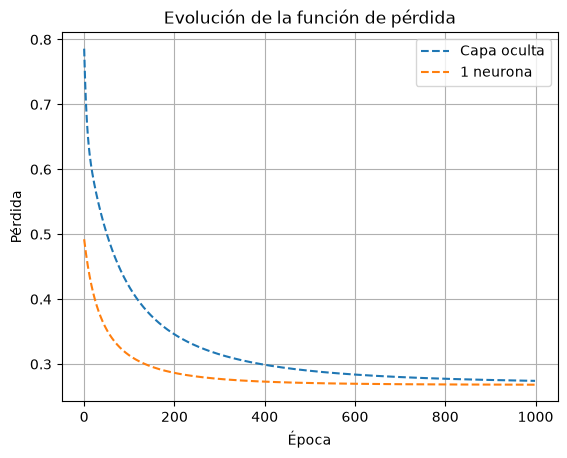

In [67]:
# Curva de perdida
plt.plot(losses, label="Capa oculta", linestyle='--')
plt.plot(loss_ce_list, label="1 neurona", linestyle='--')
plt.xlabel("Época")
plt.ylabel("Pérdida")
#plt.yscale("log")
plt.legend()
plt.title("Evolución de la función de pérdida")
plt.grid()
plt.show()

## QUIZ SEMANA 2:

### 1. Explicación y aprendizajes

El código carga los datos de lluvia y casos de dengue desde un archivo de Excel. Después, organiza las variables y las normaliza usando Z-score para facilitar el entrenamiento. Luego define una regresión logística con función sigmoide y entropía cruzada como pérdida. Sus gradientes se calculan mediante la regla de la cadena y los parámetros se ajustan con descenso por gradiente.

Posteriormente, se construye una capa oculta con varias neuronas. En este laboratorio, sus pesos y sesgos se generan aleatoriamente y permanecen fijos; únicamente se entrenan los pesos y el sesgo de la capa de salida. Finalmente, se calculan las probabilidades, las métricas de desempeño y se comparan diferentes cantidades de neuronas ocultas.

Mis tres principales aprendizajes fueron:

1. La regla de la cadena permite calcular cómo debe cambiar cada parámetro para reducir el error mediante *backpropagation*.
2. Las dimensiones de los arreglos son importantes: `np.ravel()`, `np.flatten()`, `np.outer()` y `np.newaxis` ayudan a realizar correctamente las operaciones con vectores y matrices.
3. Aumentar el número de neuronas no garantiza un mejor *accuracy*. El resultado también depende de los datos, la inicialización y de qué parámetros se entrenan.

### 2. Diferencia entre `np.ravel()` y `np.flatten()`

Ambas funciones convierten un arreglo en un vector unidimensional. `np.ravel()` intenta devolver una vista del arreglo original, por lo que puede usar menos memoria. `np.flatten()` siempre crea una copia independiente.

En el código, `np.ravel()` transforma `X_escalado` y `Y_escalado` de dimensión `(n, 1)` a `(n,)`, facilitando las operaciones de la capa oculta. También se usa `W1.flatten()` para convertir los pesos de la capa oculta en un vector antes de aplicar `np.outer()`. Esto es importante porque las dimensiones deben ser compatibles para multiplicar los datos por los pesos y obtener una matriz de activaciones.

### 3. Retropropagación

La retropropagación calcula cómo influye cada peso y sesgo en la función de pérdida. Primero, la red realiza una propagación hacia adelante:

$$Z_1=XW_1+b_1,\qquad H=\sigma(Z_1),\qquad \hat{Y}=\sigma(HW_2+b_2).$$

Después, se compara $\hat{Y}$ con los valores reales y se aplica la regla de la cadena para calcular los gradientes. Para la capa de salida, el error es

$$\delta_2=\hat{Y}-Y.$$

Este error permite actualizar los parámetros mediante

$$W\leftarrow W-\eta\frac{\partial L}{\partial W},\qquad b\leftarrow b-\eta\frac{\partial L}{\partial b}.$$

Para hacer ajustables los pesos y sesgos de la capa oculta, el error debe propagarse hacia ella considerando la derivada de la función sigmoide:

$$\delta_1=(\delta_2W_2^T)\odot\sigma'(Z_1).$$

Así se pueden calcular los gradientes de `W1` y `b1` y actualizarlos.

4. Corra el modelo con distintos números de neuronas en la única capa oculta *(1, 5, 10, 15, 20, 25, 30)*, y haga una gráfica que en el eje x tenga el número de neuronas de la única capa oculta, y en el eje y tenga el valor del *accuracy*. ¿Que puede concluir al respecto? **Nota:** Asegurese que sus redes lleguen a la convergencia.

Esta función recibe el número de neuronas ocultas, genera los pesos fijos de la capa oculta, entrena la capa de salida mediante gradiente descendente y devuelve el accuracy final.

In [68]:
# Función para entrenar una red con N neuronas en la capa oculta
# Devuelve el accuracy, la curva de pérdida y las predicciones finales.
def entrenar_con_ocultas(N_neu, X, y, lr=0.1, epochs=1000, seed=42):
    # Fijamos semilla para reproducibilidad (cada N tendrá sus propios pesos)
    np.random.seed(seed)

    # Pesos fijos de la capa oculta
    W1 = np.random.randn(1, N_neu)
    b1 = np.random.randn(N_neu)

    # Capa oculta (fija)
    def hidden_layer(X):
        z = np.outer(X, W1.flatten()) + b1
        return 1 / (1 + np.exp(-z))

    # Modelo completo (capa oculta fija + capa de salida entrenable)
    def predict_hidd(X, w, b):
        h = hidden_layer(X)
        y = h @ w + b
        return 1 / (1 + np.exp(-y))

    # Inicialización de la capa de salida
    w = np.random.randn(N_neu)
    b = np.random.randn()

    losses = []
    for epoch in range(epochs):
        y_pred = predict_hidd(X, w, b)
        loss = loss_ce(y_pred, y)

        # Gradiente
        h = hidden_layer(X)
        error = (y_pred - y)[:, np.newaxis]
        dw = np.mean(h * error, axis=0)
        db = np.mean(y_pred - y)

        w -= lr * dw
        b -= lr * db
        losses.append(loss)

        # Early stopping si la pérdida cambia muy poco
        if epoch > 0 and abs(losses[-1] - losses[-2]) < 1e-10:
            break

    # Predicción final y cálculo de accuracy
    y_pred_final = predict_hidd(X, w, b)
    y_pred_bin = (y_pred_final >= 0.5).astype(int)
    accuracy = np.mean(y_pred_bin == y)
    return accuracy, losses, y_pred_bin

Se prueban las cantidades solicitadas y se almacenan los accuracies.

In [69]:
# Lista de números de neuronas a probar
neuronas = [1, 5, 10, 15, 20, 25, 30]
accuracies = []
curvas_perdida = []
predicciones_modelos = []

print("Entrenando redes con diferente número de neuronas ocultas...")
for n in neuronas:
    acc, curva, predicciones = entrenar_con_ocultas(
        n, X_escalado, Y_escalado, lr=0.1, epochs=10000
    )
    accuracies.append(acc)
    curvas_perdida.append(curva)
    predicciones_modelos.append(predicciones)
    print(f"Neuronas ocultas: {n:2d}  ->  Accuracy: {acc:.4f}")

Entrenando redes con diferente número de neuronas ocultas...
Neuronas ocultas:  1  ->  Accuracy: 0.9000
Neuronas ocultas:  5  ->  Accuracy: 0.9000
Neuronas ocultas: 10  ->  Accuracy: 0.9000
Neuronas ocultas: 15  ->  Accuracy: 0.9000
Neuronas ocultas: 20  ->  Accuracy: 0.9000
Neuronas ocultas: 25  ->  Accuracy: 0.9000
Neuronas ocultas: 30  ->  Accuracy: 0.9000


Se visualiza la relación entre la cantidad de neuronas y el desempeño del modelo.

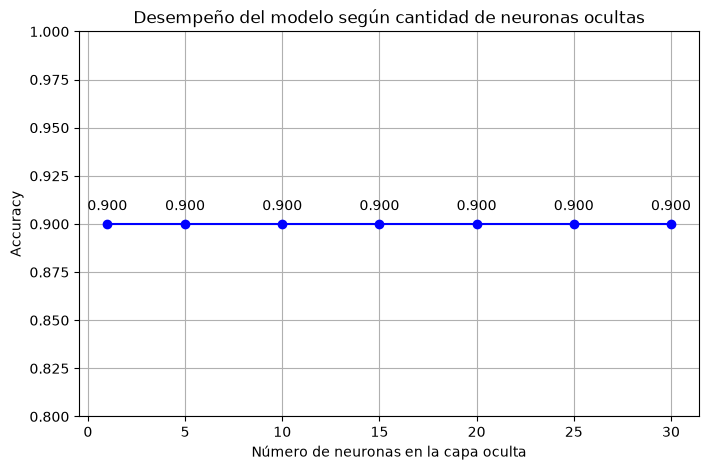

In [70]:
plt.figure(figsize=(8,5))
plt.plot(neuronas, accuracies, marker='o', linestyle='-', color='b')
plt.xlabel("Número de neuronas en la capa oculta")
plt.ylabel("Accuracy")
plt.title("Desempeño del modelo según cantidad de neuronas ocultas")
plt.grid(True)
plt.ylim(0.8, 1.0)   # Ajustar según los resultados
for i, txt in enumerate(accuracies):
    plt.annotate(f"{txt:.3f}", (neuronas[i], accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.show()

### Convergencia y matrices de confusión

La siguiente gráfica muestra la evolución de la pérdida durante el entrenamiento para cada cantidad de neuronas. Después se presentan las matrices de confusión correspondientes a las predicciones finales de cada modelo.

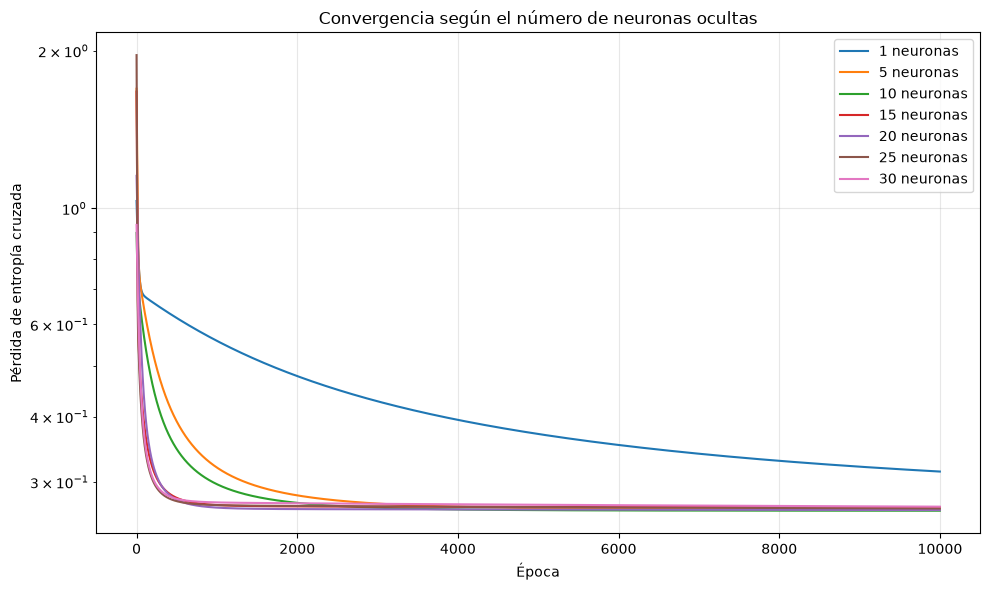

In [71]:
# Curvas de convergencia de todos los modelos
plt.figure(figsize=(10, 6))
for n, curva in zip(neuronas, curvas_perdida):
    plt.plot(curva, label=f"{n} neuronas")

plt.xlabel("Época")
plt.ylabel("Pérdida de entropía cruzada")
plt.title("Convergencia según el número de neuronas ocultas")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

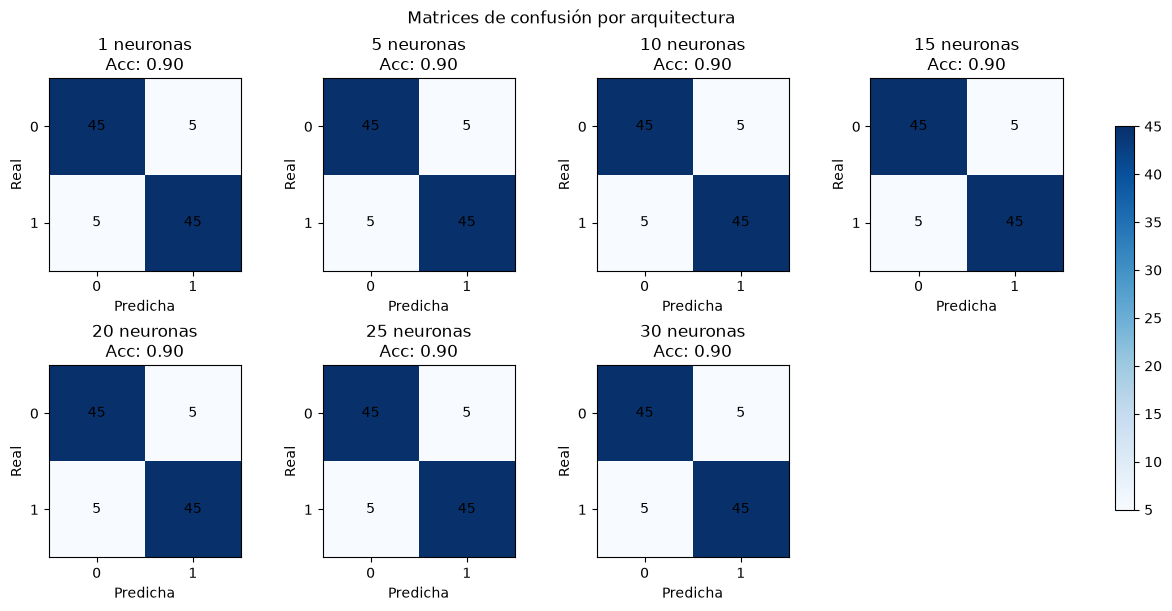

In [72]:
# Matrices de confusión de todos los modelos
y_true = Y_escalado.astype(int).ravel()
fig, axes = plt.subplots(
    2, 4, figsize=(12, 6), constrained_layout=True
 )
axes = axes.ravel()

for i, (n, y_pred) in enumerate(zip(neuronas, predicciones_modelos)):
    matriz = np.zeros((2, 2), dtype=int)
    for real, predicha in zip(y_true, y_pred.ravel().astype(int)):
        matriz[real, predicha] += 1

    imagen = axes[i].imshow(matriz, cmap="Blues")
    axes[i].set_title(f"{n} neuronas\nAcc: {accuracies[i]:.2f}")
    axes[i].set_xlabel("Predicha")
    axes[i].set_ylabel("Real")
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    for fila in range(2):
        for columna in range(2):
            axes[i].text(
                columna, fila, matriz[fila, columna],
                ha="center", va="center"
            )

axes[-1].axis("off")
fig.colorbar(imagen, ax=axes[:len(neuronas)], shrink=0.8)
fig.suptitle("Matrices de confusión por arquitectura")
plt.show()

**Conclusiones del experimento**

- **Desempeño:** En esta ejecución, todas las arquitecturas alcanzan un *accuracy* de aproximadamente `0.90`. Aumentar el número de neuronas no produjo una mejora visible en la clasificación.

- **Convergencia:** Las curvas de pérdida disminuyen rápidamente al comienzo y luego se estabilizan. Se usaron hasta `10000` épocas para permitir que la capa de salida convergiera; la convergencia es asintótica, especialmente en el modelo con una neurona.

- **Matrices de confusión:** La mayoría de los modelos obtiene `45` verdaderos negativos, `45` verdaderos positivos, `5` falsos positivos y `5` falsos negativos. Por tanto, el `accuracy` de `0.90` es consistente con las matrices.

- **Interpretación:** La capa oculta genera características fijas y solo se entrenan los pesos y el sesgo de salida. Por eso, agregar neuronas no garantiza una mejor representación ni un mejor resultado.

- **Limitación:** La evaluación se realiza sobre las mismas 100 observaciones usadas para entrenar. Por ello, el `accuracy` describe el ajuste a estos datos, pero no permite medir completamente la capacidad de generalización del modelo.

5. Para los modelos del punto anterior con 1, 15 y 30 neuronas de la única capa oculta, haga los esquemas de las redes (el gráfico con sus neuronas, variables de entrada, y la neurona de salida), sume el total de pesos y bias tanto para las capas ocultas como para la ajustable para reportar el número total de parámetros, y muestre las transformaciones algebraicas en terminos de dimensiones de matrices a cada nivel de la red. (Dimensión datos entrada, dimensión salida de la capa oculta, dimensión salida unica neurona ajustable).

# Punto 5. Esquemas, parámetros y transformaciones de las redes neuronales

Para los modelos considerados se construyen redes neuronales con una única capa oculta, variando el número de neuronas entre $1$, $15$ y $30$. En todos los casos se tiene una única variable de entrada, $X_1$, y una única neurona de salida.

El conjunto de datos de entrada contiene $100$ observaciones. En la implementación, después de aplicar `np.ravel()`, la variable de entrada tiene dimensión $(100,)$. En términos matriciales de la red, esto se traduce como una matriz columna de dimensión $100\times1$:

$$
X\in\mathbb{R}^{100\times1}.
$$

De esta manera, cada una de las $100$ filas corresponde a una observación y la única columna corresponde a la variable de entrada $X_1$.

La estructura general de la red puede representarse como

$$
X_{100\times1}
\longrightarrow
H_{100\times N}
\longrightarrow
\hat{Y}_{100\times1},
$$

donde $N$ representa el número de neuronas de la única capa oculta.

La función de activación utilizada tanto en la capa oculta como en la neurona de salida es la función sigmoide, definida como

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Donde $z = WX+b$.

## Red con una neurona oculta

Cuando la capa oculta contiene una única neurona, la arquitectura de la red es:

```mermaid
graph LR
    X1((X₁)) -->|w₁| H1((H₁<br/>b₁<br/>σ))
    H1 -->|v₁| Y((ŷ<br/>b<br/>σ))
```

La entrada está formada por $100$ observaciones de la única variable $X_1$, por lo que

$$
X\in\mathbb{R}^{100\times1}.
$$

La transformación hacia la capa oculta utiliza una matriz de pesos de dimensión

$$
W\in\mathbb{R}^{1\times1}
$$

y un bias de dimensión

$$
b_1\in\mathbb{R}^{1\times1}.
$$

La salida de la capa oculta tiene entonces dimensión

$$
H\in\mathbb{R}^{100\times1}.
$$

La neurona de salida recibe esta representación y utiliza un peso

$$
v\in\mathbb{R}^{1\times1}
$$

y un bias escalar

$$
b\in\mathbb{R}.
$$

La primera transformación de la red realiza inicialmente una combinación lineal:

$$
\underbrace{X}_{100\times1}
\underbrace{W}_{1\times1}
+
\underbrace{b_1}_{1\times1}
=
\underbrace{Z}_{100\times1}.
$$

Posteriormente, se aplica la función de activación sigmoide:

$$
\underbrace{H}_{100\times1}
=
\sigma\left(
\underbrace{Z}_{100\times1}
\right).
$$

La neurona de salida realiza primero la combinación lineal

$$
\underbrace{H}_{100\times1}
\underbrace{v}_{1\times1}
+
\underbrace{b}_{1\times1}
=
\underbrace{Z_{\mathrm{salida}}}_{100\times1}.
$$

Finalmente, se aplica nuevamente la función de activación sigmoide para obtener la predicción:

$$
\underbrace{\hat{Y}}_{100\times1}
=
\sigma\left(
\underbrace{Z_{\mathrm{salida}}}_{100\times1}
\right).
$$

Por lo tanto, la transformación completa de la red puede expresarse como

$$
\boxed{
\hat{Y}
=
\sigma\left(
\sigma(XW+b_1)v+b
\right)
}.
$$

La red contiene $1$ peso y $1$ bias en la capa oculta, además de $1$ peso y $1$ bias en la capa de salida. Por lo tanto, el número total de parámetros es

$$
1+1+1+1=\boxed{4}.
$$

En este laboratorio, los parámetros $W$ y $b_1$ de la capa oculta permanecen fijos. Los parámetros que se ajustan durante el entrenamiento son únicamente el peso $v$ y el bias $b$ de la neurona de salida.


## Red con quince neuronas ocultas

Cuando la capa oculta contiene $15$ neuronas, la única variable de entrada $X_1$ se conecta con cada una de las neuronas de la capa oculta. Cada neurona genera una representación diferente de la entrada, por lo que la salida de esta capa tiene $15$ componentes para cada observación.

```mermaid
graph LR
    X1((X₁))

    H1((H₁<br/>b₁<br/>σ))
    H2((H₂<br/>b₂<br/>σ))
    H3((H₃<br/>b₃<br/>σ))
    H4((⋮))
    H15((H₁₅<br/>b₁₅<br/>σ))

    Y((ŷ<br/>b<br/>σ))

    X1 -->|w₁| H1
    X1 -->|w₂| H2
    X1 -->|w₃| H3
    X1 -->|⋯| H4
    X1 -->|w₁₅| H15

    H1 -->|v₁| Y
    H2 -->|v₂| Y
    H3 -->|v₃| Y
    H4 -->|⋯| Y
    H15 -->|v₁₅| Y
```

La entrada mantiene su dimensión

$$
X\in\mathbb{R}^{100\times1}.
$$

Como existen $15$ neuronas ocultas, la matriz de pesos que conecta la entrada con esta capa tiene dimensión

$$
W\in\mathbb{R}^{1\times15},
$$

mientras que el vector de bias tiene dimensión

$$
b_1\in\mathbb{R}^{15\times1}.
$$

La transformación matricial hacia la capa oculta primero realiza una combinación lineal:

$$
\underbrace{X}_{100\times1}
\underbrace{W}_{1\times15}
+
\underbrace{b_1}_{15\times1}
=
\underbrace{Z}_{100\times15}.
$$

La multiplicación de matrices tiene dimensiones

$$
(100\times1)(1\times15)=100\times15,
$$

por lo que cada una de las $100$ observaciones queda representada mediante $15$ valores, correspondientes a las $15$ neuronas de la capa oculta.

Posteriormente, se aplica la función de activación sigmoide a cada componente de $Z$:

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Por tanto, la salida de la capa oculta está dada por

$$
\underbrace{H}_{100\times15}
=
\sigma\left(
\underbrace{Z}_{100\times15}
\right).
$$

En este caso, la matriz de pesos está formada por los pesos que conectan la única variable de entrada con las $15$ neuronas ocultas:

$$
W=
\begin{bmatrix}
w_1 & w_2 & \cdots & w_{15}
\end{bmatrix}
\in\mathbb{R}^{1\times15}.
$$

El vector de bias de la capa oculta está dado por

$$
b_1=
\begin{bmatrix}
b_1\\
b_2\\
\vdots\\
b_{15}
\end{bmatrix}
\in\mathbb{R}^{15\times1}.
$$

La capa de salida combina estas $15$ representaciones mediante un vector de pesos

$$
v=
\begin{bmatrix}
v_1\\
v_2\\
\vdots\\
v_{15}
\end{bmatrix}
\in\mathbb{R}^{15\times1}
$$

y un bias escalar $b$.

Primero se realiza la combinación lineal

$$
\underbrace{H}_{100\times15}
\underbrace{v}_{15\times1}
+
\underbrace{b}_{1\times1}
=
\underbrace{Z_{\mathrm{salida}}}_{100\times1}.
$$

La multiplicación de matrices tiene dimensiones

$$
(100\times15)(15\times1)=100\times1.
$$

Finalmente, se aplica nuevamente la función de activación sigmoide:

$$
\underbrace{\hat{Y}}_{100\times1}
=
\sigma\left(
\underbrace{Z_{\mathrm{salida}}}_{100\times1}
\right).
$$

Por lo tanto, la transformación completa de la red puede expresarse como

$$
\boxed{
\hat{Y}
=
\sigma\left(
\sigma(XW+b_1)v+b
\right)
}.
$$

El número total de parámetros es

$$
15+15+15+1=\boxed{46}.
$$

De estos $46$ parámetros, $30$ pertenecen a la capa oculta: $15$ pesos y $15$ bias. Los otros $16$ corresponden a la capa de salida: $15$ pesos y $1$ bias. Sin embargo, dado que la capa oculta permanece fija durante el entrenamiento, únicamente los $16$ parámetros de la capa de salida son ajustables.


## Red con treinta neuronas ocultas

Para la tercera arquitectura se utilizan $30$ neuronas en la única capa oculta. En este caso, cada una de las $100$ observaciones de entrada se transforma en una representación de $30$ componentes.

```mermaid
graph LR
    X1((X₁))

    H1((H₁<br/>b₁<br/>σ))
    H2((H₂<br/>b₂<br/>σ))
    H3((H₃<br/>b₃<br/>σ))
    H4((⋮))
    H30((H₃₀<br/>b₃₀<br/>σ))

    Y((ŷ<br/>b<br/>σ))

    X1 -->|w₁| H1
    X1 -->|w₂| H2
    X1 -->|w₃| H3
    X1 -->|⋯| H4
    X1 -->|w₃₀| H30

    H1 -->|v₁| Y
    H2 -->|v₂| Y
    H3 -->|v₃| Y
    H4 -->|⋯| Y
    H30 -->|v₃₀| Y
```

La matriz de pesos de la capa de entrada a la capa oculta tiene dimensión

$$
W\in\mathbb{R}^{1\times30},
$$

y el vector de bias de la capa oculta tiene dimensión

$$
b_1\in\mathbb{R}^{30\times1}.
$$

La transformación hacia la capa oculta primero realiza una combinación lineal:

$$
\underbrace{X}_{100\times1}
\underbrace{W}_{1\times30}
+
\underbrace{b_1}_{30\times1}
=
\underbrace{Z}_{100\times30}.
$$

La multiplicación de matrices tiene dimensiones

$$
(100\times1)(1\times30)=100\times30,
$$

por lo que cada una de las $100$ observaciones queda representada mediante $30$ valores, correspondientes a las $30$ neuronas de la capa oculta.

Posteriormente, se aplica la función de activación sigmoide:

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Por tanto, la salida de la capa oculta está dada por

$$
\underbrace{H}_{100\times30}
=
\sigma\left(
\underbrace{Z}_{100\times30}
\right).
$$

En este caso, la matriz de pesos y el vector de bias pueden escribirse como

$$
W=
\begin{bmatrix}
w_1 & w_2 & w_3 & \cdots & w_{30}
\end{bmatrix}
\in\mathbb{R}^{1\times30},
$$

y

$$
b_1=
\begin{bmatrix}
b_1\\
b_2\\
b_3\\
\vdots\\
b_{30}
\end{bmatrix}
\in\mathbb{R}^{30\times1}.
$$

La neurona de salida combina las $30$ representaciones de la capa oculta mediante un vector de pesos

$$
v=
\begin{bmatrix}
v_1\\
v_2\\
v_3\\
\vdots\\
v_{30}
\end{bmatrix}
\in\mathbb{R}^{30\times1}
$$

y un bias escalar $b$.

Primero se realiza la combinación lineal

$$
\underbrace{H}_{100\times30}
\underbrace{v}_{30\times1}
+
\underbrace{b}_{1\times1}
=
\underbrace{Z_{\mathrm{salida}}}_{100\times1}.
$$

La multiplicación de matrices tiene dimensiones

$$
(100\times30)(30\times1)=100\times1.
$$

Finalmente, se aplica nuevamente la función de activación sigmoide:

$$
\underbrace{\hat{Y}}_{100\times1}
=
\sigma\left(
\underbrace{Z_{\mathrm{salida}}}_{100\times1}
\right).
$$

Por lo tanto, la transformación completa de la red puede expresarse como

$$
\boxed{
\hat{Y}
=
\sigma\left(
\sigma(XW+b_1)v+b
\right)
}.
$$

El número total de parámetros de esta arquitectura es

$$
30+30+30+1=\boxed{91}.
$$

De los $91$ parámetros, $60$ pertenecen a la capa oculta, correspondientes a $30$ pesos y $30$ bias. Los $31$ restantes pertenecen a la neurona de salida, correspondientes a $30$ pesos y $1$ bias. Como la capa oculta se mantiene fija, únicamente estos $31$ parámetros de la capa de salida son ajustados durante el entrenamiento.


## Transformaciones algebraicas generales

Las tres arquitecturas pueden describirse mediante una expresión general utilizando $N$ neuronas en la capa oculta. La entrada está dada por

$$
X\in\mathbb{R}^{100\times1}.
$$

La primera transformación utiliza

$$
W\in\mathbb{R}^{1\times N}
$$

y

$$
b_1\in\mathbb{R}^{N\times1}.
$$

Primero se realiza la combinación lineal

$$
Z=XW+b_1,
$$

donde las dimensiones de la operación son

$$
(100\times1)(1\times N)+(N\times1)
\longrightarrow
100\times N.
$$

Posteriormente, se aplica la función de activación sigmoide:

$$
H=\sigma(Z),
$$

por lo que

$$
H\in\mathbb{R}^{100\times N}.
$$

La segunda transformación corresponde a la única neurona de salida. Para esta capa se tiene

$$
v\in\mathbb{R}^{N\times1}
$$

y

$$
b\in\mathbb{R}.
$$

Primero se realiza la combinación lineal

$$
Z_{\mathrm{salida}}=Hv+b,
$$

con dimensiones

$$
(100\times N)(N\times1)+(1)
\longrightarrow
100\times1.
$$

Finalmente, se aplica nuevamente la función de activación sigmoide:

$$
\hat{Y}=\sigma(Z_{\mathrm{salida}}).
$$

Por lo tanto, la transformación completa de la red puede resumirse como

$$
\boxed{
\hat{Y}
=
\sigma\left(
\sigma(XW+b_1)v+b
\right)
}.
$$

Equivalentemente, en términos de dimensiones,

$$
\mathbb{R}^{100\times1}
\xrightarrow{\;W,b_1,\sigma\;}
\mathbb{R}^{100\times N}
\xrightarrow{\;v,b,\sigma\;}
\mathbb{R}^{100\times1},
$$

donde

$$
N\in\{1,15,30\}.
$$

El número total de parámetros de la arquitectura general se obtiene sumando los pesos y bias de ambas capas. La capa oculta contiene $N$ pesos y $N$ bias, mientras que la neurona de salida contiene $N$ pesos y un bias. Por tanto,

$$
N+N+N+1=3N+1.
$$

Así, para las tres arquitecturas estudiadas se obtiene:

| Neuronas ocultas | $W$ | $b_1$ | $v$ | $b$ | Parámetros totales |
|-----------------:|:---:|:-----:|:---:|:---:|-------------------:|
| $1$              | $1\times1$ | $1$ | $1\times1$ | $1$ | $\boxed{4}$ |
| $15$             | $1\times15$ | $15$ | $15\times1$ | $1$ | $\boxed{46}$ |
| $30$             | $1\times30$ | $30$ | $30\times1$ | $1$ | $\boxed{91}$ |

Es importante distinguir entre el **número total de parámetros de la arquitectura** y el **número de parámetros ajustables durante el entrenamiento**. En este laboratorio, $W$ y $b_1$ permanecen fijos, por lo que los únicos parámetros que se modifican durante el ajuste son $v$ y $b$. En consecuencia, el número de parámetros ajustables es

$$
N+1.
$$

Para las tres configuraciones esto corresponde a $2$, $16$ y $31$ parámetros ajustables, respectivamente.